In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans

Read the file to a dataframe

In [4]:
df=pd.read_excel("WEOOct2020all.xlsx", engine='openpyxl')

In [133]:
df.head()

,WEO Country Code,ISO,WEO Subject Code,Country,Subject Descriptor,Subject Notes,Units,Scale,Country/Series-specific Notes,1980,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Estimates Start After
0,512,AFG,NGDP_R,Afghanistan,"Gross domestic product, constant prices",Expressed in billions of national currency uni...,National currency,Billions,Source: National Statistics Office Latest actu...,NaN,...,1255.288,1270.216,1319.902,1253.906,1304.063,1363.06,1424.397,1481.497,1540.937,2019.0
1,512,AFG,NGDP_RPCH,Afghanistan,"Gross domestic product, constant prices",Annual percentages of constant price GDP are y...,Percent change,NaN,"See notes for: Gross domestic product, consta...",NaN,...,2.647,1.189,3.912,-5,4,4.524,4.5,4.009,4.012,2019.0
2,512,AFG,NGDP,Afghanistan,"Gross domestic product, current prices",Expressed in billions of national currency uni...,National currency,Billions,Source: National Statistics Office Latest actu...,NaN,...,1285.46,1327.69,1469.596,1465.922,1597.738,1741.832,1893.023,2047.665,2215.013,2019.0
3,512,AFG,NGDPD,Afghanistan,"Gross domestic product, current prices",Values are based upon GDP in national currency...,U.S. dollars,Billions,"See notes for: Gross domestic product, curren...",NaN,...,18.91,18.401,18.876,19.006,19.692,20.829,22.022,23.169,24.372,2019.0
4,512,AFG,PPPGDP,Afghanistan,"Gross domestic product, current prices",These data form the basis for the country weig...,Purchasing power parity; international dollars,Billions,"See notes for: Gross domestic product, curren...",NaN,...,74.712,77.416,81.88,78.884,83.852,89.205,94.908,100.6,106.685,2019.0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8777 entries, 0 to 8776
Data columns (total 56 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   WEO Country Code               8776 non-null   object 
 1   ISO                            8775 non-null   object 
 2   WEO Subject Code               8775 non-null   object 
 3   Country                        8775 non-null   object 
 4   Subject Descriptor             8775 non-null   object 
 5   Subject Notes                  8580 non-null   object 
 6   Units                          8775 non-null   object 
 7   Scale                          3900 non-null   object 
 8   Country/Series-specific Notes  7589 non-null   object 
 9   1980                           3879 non-null   object 
 10  1981                           4008 non-null   object 
 11  1982                           4049 non-null   object 
 12  1983                           4091 non-null   o

In [11]:
df.columns

Index([     'WEO Country Code',                   'ISO',
            'WEO Subject Code',               'Country',
                          1980,                    1981,
                          1982,                    1983,
                          1984,                    1985,
                          1986,                    1987,
                          1988,                    1989,
                          1990,                    1991,
                          1992,                    1993,
                          1994,                    1995,
                          1996,                    1997,
                          1998,                    1999,
                          2000,                    2001,
                          2002,                    2003,
                          2004,                    2005,
                          2006,                    2007,
                          2008,                    2009,
                          2010,

In [5]:
#Some null values are filled with '--'
symbol_to_find = '--'

# Check if any element in the DataFrame contains the symbol
contains_symbol = df.applymap(lambda x: symbol_to_find in str(x))

# Get rows where any column contains the symbol
rows_with_symbol = df[contains_symbol.any(axis=1)]

C:\Users\Iveta\AppData\Local\Temp\ipykernel_20764\2085958995.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  contains_symbol = df.applymap(lambda x: symbol_to_find in str(x))


In [6]:
#Replace the symbol with Nan values for an easier imputation
df.replace('--', np.nan, inplace=True)

In [7]:
#Drop the explanatory columns
df=df.drop(['Subject Descriptor', 'Units', 'Country/Series-specific Notes', 'Subject Notes', 'Scale'], axis=1)

In [8]:
#Drop last two rows as it does not contain information about countries
df=df.drop(df.index[-2:])

#### Part 1: top 10 countries that grew "Gross domestic product per capita" the most over the last decade

In [8]:
#NGDPRPPPPC (Gross domestic product per capita, constant prices, expressed in PPP) will be used to compare countries
#Also notable that for each country estimations starts at different year. For the sake of simplicity that is not considered here
top_gdp=df[df['WEO Subject Code']=='NGDPRPPPPC']
top_gdp=top_gdp.loc[:,['Country', 'WEO Subject Code',
                        2009, 2010, 2011, 2012, 2013,
                        2014, 2015, 2016, 2017, 2018,
                        2019]]

In [9]:
#Syria appears to have missing data but we can ignore that as it does not fall in our top countries
top_gdp.loc[7567]

Country                  Syria
WEO Subject Code    NGDPRPPPPC
2009                       NaN
2010                       NaN
2011                       NaN
2012                       NaN
2013                       NaN
2014                       NaN
2015                       NaN
2016                       NaN
2017                       NaN
2018                       NaN
2019                       NaN
Name: 7567, dtype: object

In [10]:
#One way of comparing total GDP over the last decade
top_gdp['Total'] = top_gdp.iloc[:, 2:13].sum(axis=1)

#We can also compare the percentage change over the decade
top_gdp['Percentage_Change'] = ((top_gdp[2019] - top_gdp[2009]) / abs(top_gdp[2009])) * 100

In [11]:
top_gdp.head()

,Country,WEO Subject Code,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,Total,Percentage_Change
7,Afghanistan,NGDPRPPPPC,1763.843,1859.636,1919.777,2117.488,2164.844,2153.574,2111.764,2100.222,2102.784,2078.476,2111.253,22483.661,19.696197
52,Albania,NGDPRPPPPC,10570.197,11016.581,11327.429,11506.987,11643.598,11874.773,12173.644,12597.301,13088.307,13654.821,13944.393,133398.031,31.921789
97,Algeria,NGDPRPPPPC,10637.821,10804.975,10886.398,11022.002,11093.337,11274.365,11443.134,11556.853,11458.757,11385.311,11252.807,122815.760,5.781128
142,Angola,NGDPRPPPPC,7669.053,7807.484,7843.261,8265.285,8422.132,8571.165,8399.104,7937.847,7681.958,7363.118,7084.321,87044.728,-7.624566
187,Antigua and Barbuda,NGDPRPPPPC,20697.260,18925.371,18362.983,18694.803,18301.182,18708.431,19129.792,19876.074,20190.631,21267.016,21652.158,215805.701,4.613645


In [12]:
top_10_gdp_total = top_gdp.sort_values(by='Total', ascending=False).head(10)

In [13]:
top_10_gdp_total.iloc[:, [0, -2]]

,Country,Total
4552,Macao SAR,1375528.357
4507,Luxembourg,1222009.544
6307,Qatar,1121601.028
6847,Singapore,955858.372
7522,Switzerland,729285.987
3607,Ireland,720238.660
1087,Brunei Darussalam,707726.175
6532,San Marino,688808.623
5767,Norway,675724.142
8242,United Arab Emirates,666768.289


In [32]:
top_10_gdp_pc = top_gdp.sort_values(by='Percentage_Change', ascending=False).head(10)

In [34]:
top_10_gdp_pc.iloc[:, [0, -1]]

,Country,Percentage_Change
2527,Ethiopia,111.537300
1582,China,99.287075
8062,Turkmenistan,96.427474
5407,Nauru,83.632390
592,Bangladesh,75.515979
5317,Myanmar,74.754199
3427,India,74.554400
5137,Mongolia,72.538089
4192,Lao P.D.R.,72.059004
8557,Vietnam,69.501374


#### Part 2: OECD countries' "Population" growth over the last decade

In [9]:
#The data is from 2020 and by that time there were 37 OECD countries
OECD_countries_codes=['AUS', 'AUT', 'BEL', 'CAN', 'CHL', 'CZE',
                      'COL', 'DNK', 'EST', 'FIN', 'FRA', 'DEU',
                      'GRC', 'HUN', 'ISL', 'IRL', 'ISR', 'ITA',
                      'JPN', 'KOR', 'LVA', 'LTU', 'LUX', 'MEX',
                      'NLD', 'NZL', 'NOR', 'POL', 'PRT', 'SVK',
                      'SVN', 'ESP', 'SWE', 'CHE', 'TUR', 'GBR', 'USA']

In [10]:
OECD_countries=df[df['ISO'].isin(OECD_countries_codes)]

In [11]:
OECD_countries_population=OECD_countries[OECD_countries['WEO Subject Code']=='LP']

In [18]:
OECD_countries_population['Estimates Start After'].unique()

#For 4 countries estimations start at 2018 but is very slight and still shows an overall trend. 
#For simplicity the years 2009-2019 will be considered

array([2019., 2018.])

In [19]:
OECD_countries_population=OECD_countries_population.loc[:,['Country', 'WEO Subject Code',
                                                           2009, 2010, 2011, 2012, 2013,
                                                           2014, 2015, 2016, 2017, 2018,
                                                           2019]]

C:\Users\Iveta\AppData\Local\Temp\ipykernel_19384\1830385908.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(4,4))


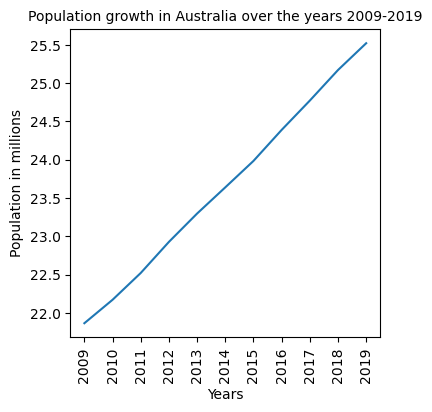

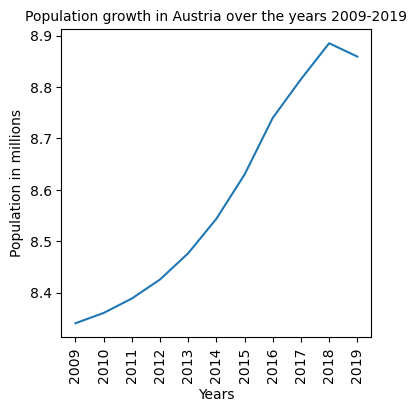

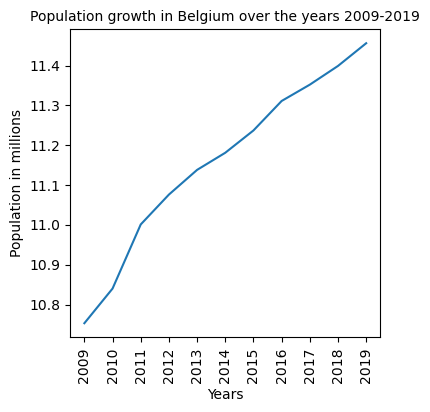

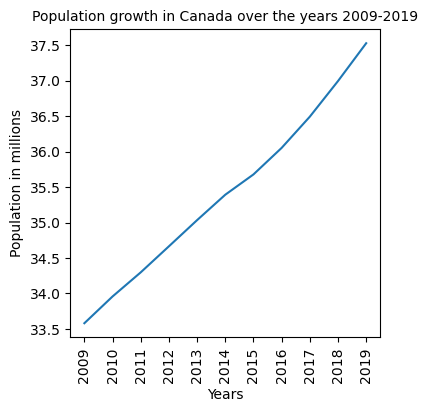

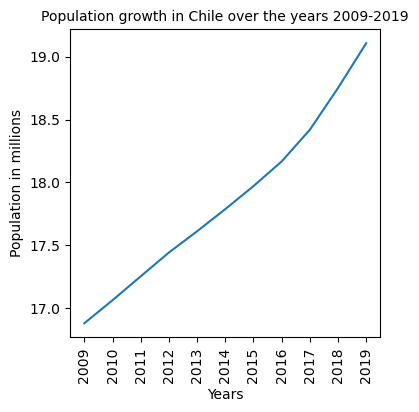

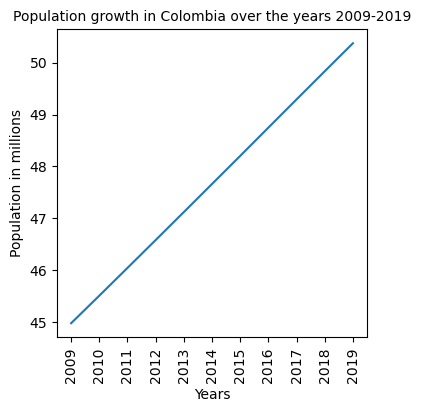

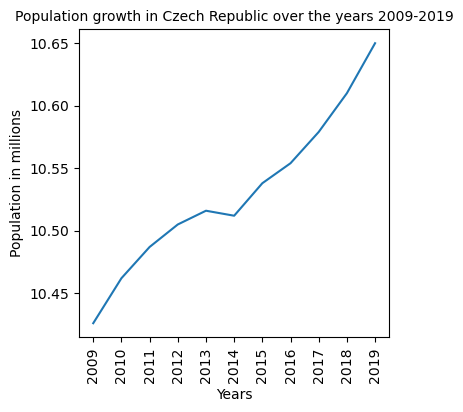

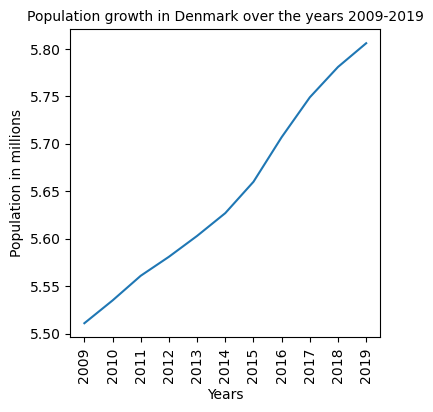

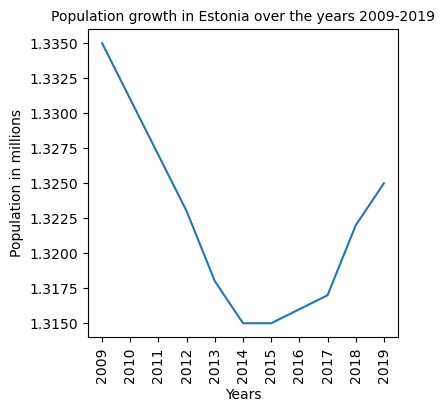

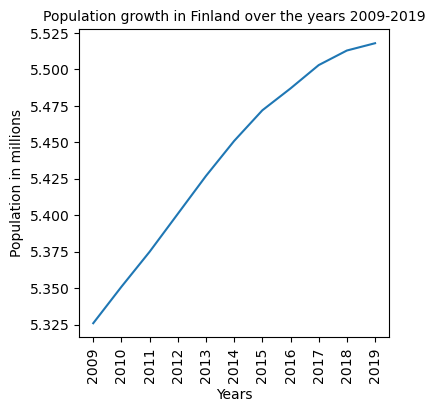

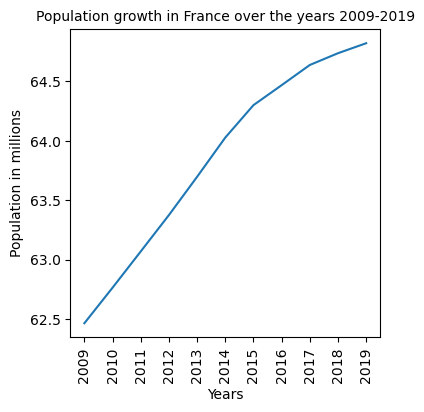

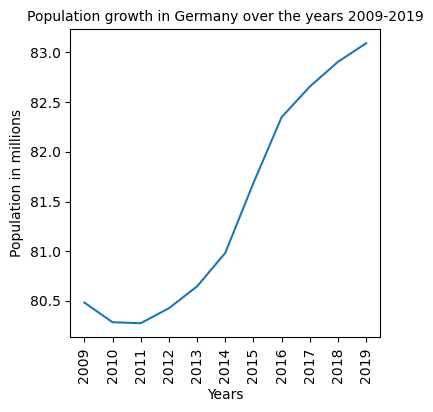

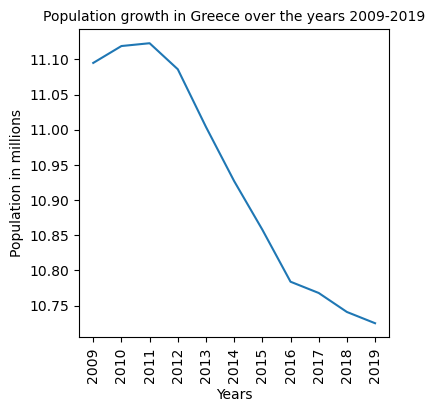

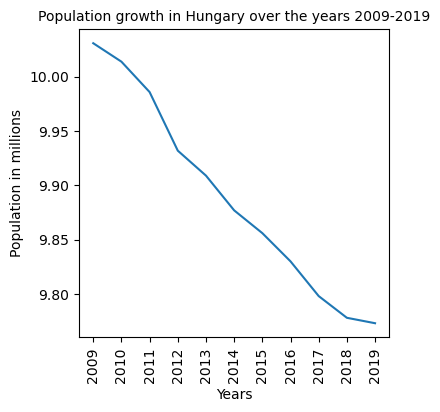

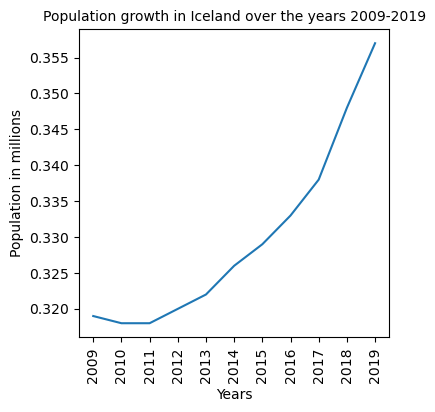

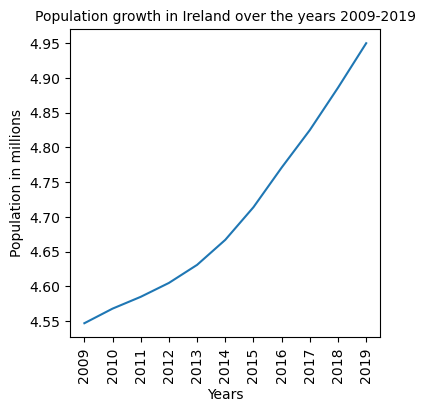

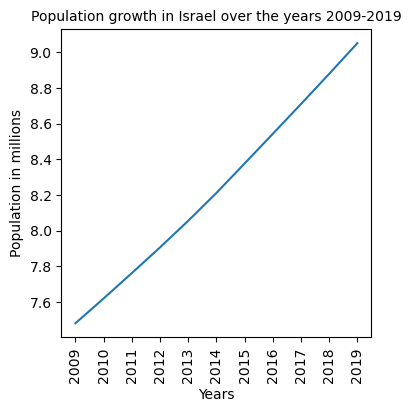

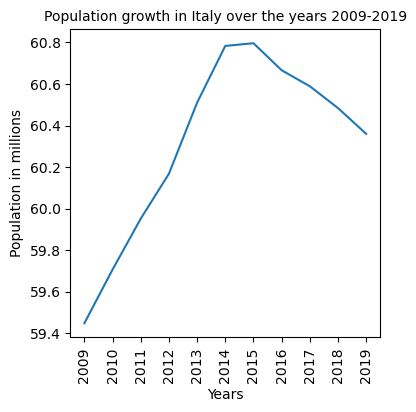

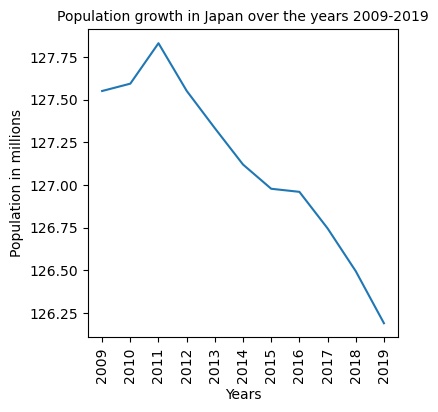

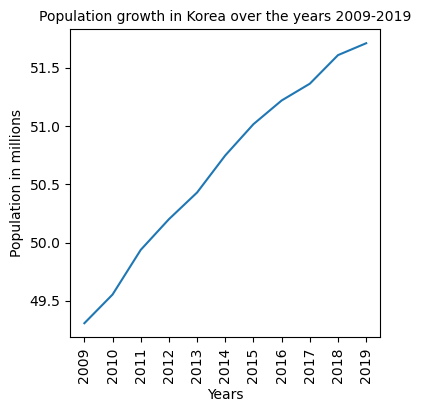

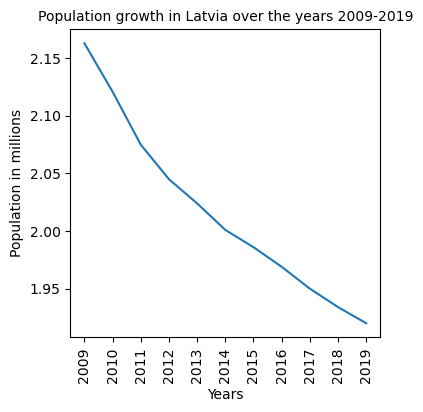

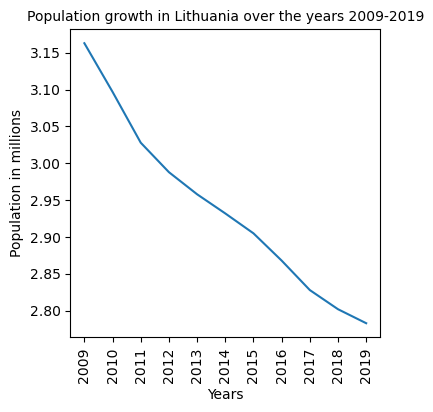

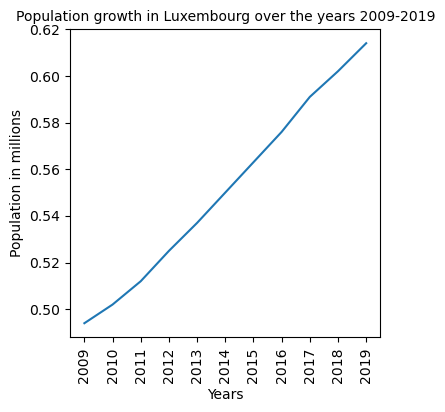

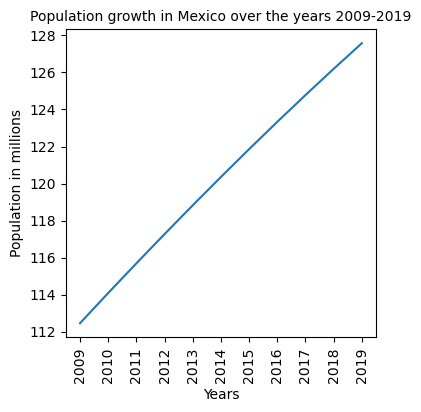

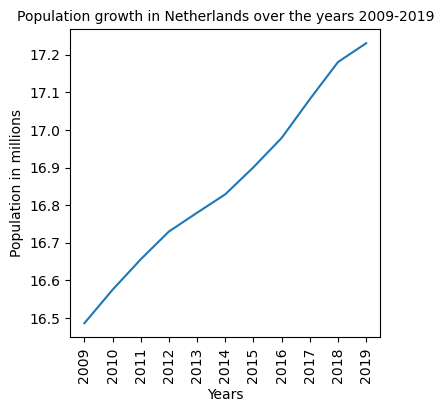

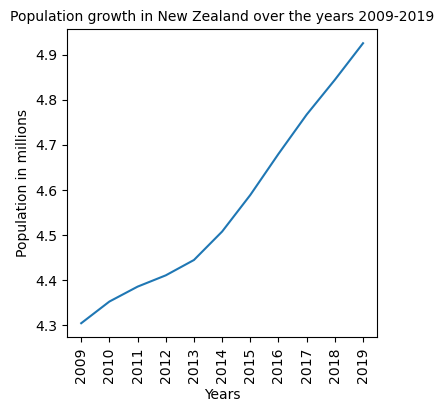

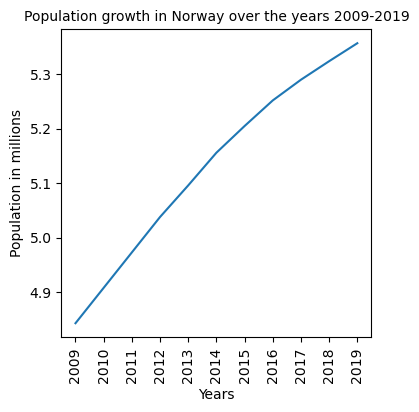

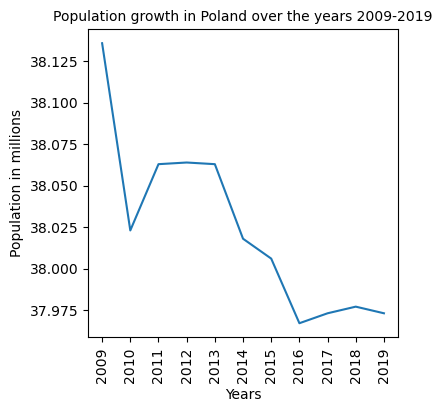

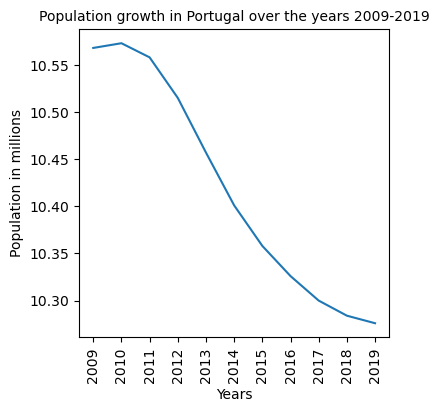

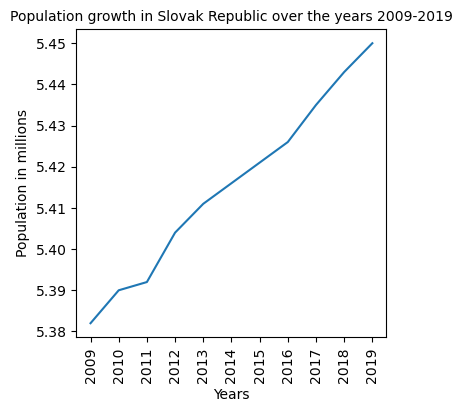

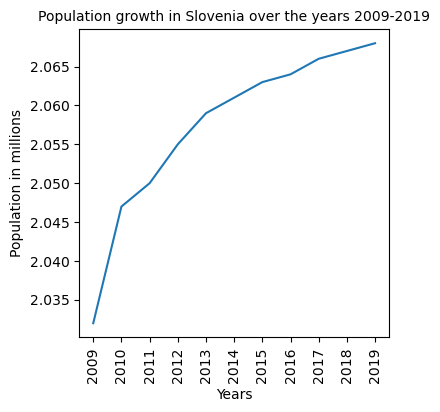

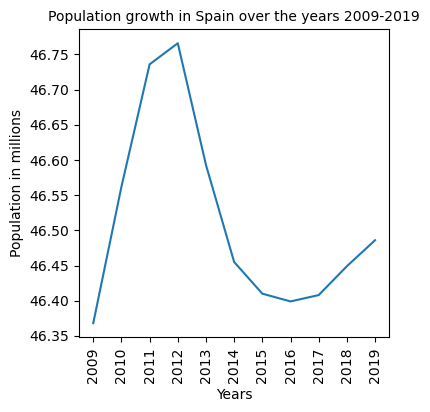

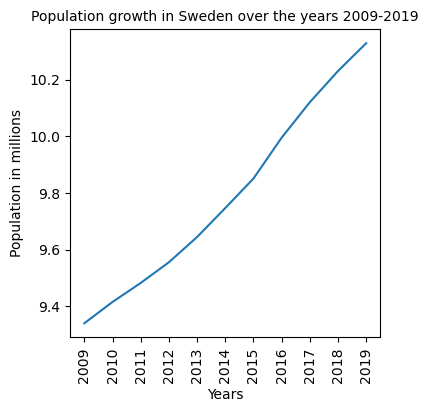

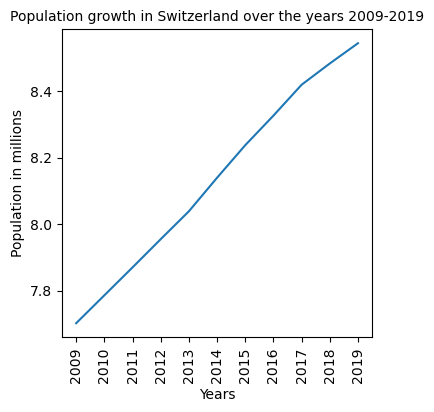

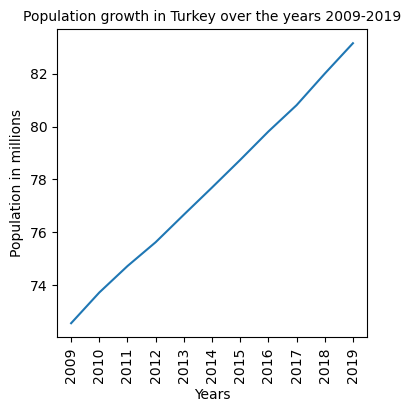

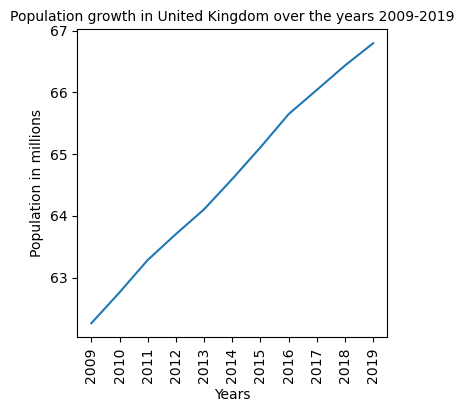

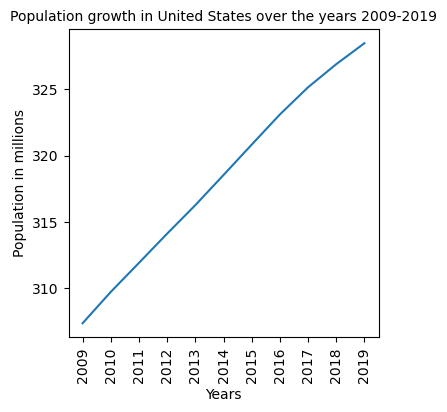

In [20]:
#Graphs of OECD countries population growth
i=0
for country in OECD_countries_population['Country']:
    x=OECD_countries_population.columns[2:]
    y=OECD_countries_population.iloc[i][2:]
    plt.figure(figsize=(4,4))
    plt.xlabel('Years')
    plt.ylabel('Population in millions')
    plt.title('Population growth in '+ country +' over the years 2009-2019', fontsize=10)
    plt.plot(x, y, label=country)
    i=i+1
    plt.xticks(np.arange(2009, 2020, 1), rotation=90)

#### Part 3: GDP growth figures as PNG

In [12]:
OECD_countries_gdp=OECD_countries[OECD_countries['WEO Subject Code']=='NGDPRPPPPC']

In [13]:
OECD_countries_gdp=OECD_countries_gdp.drop(['ISO', 'WEO Country Code'], axis=1)

In [14]:
OECD_countries_gdp=OECD_countries_gdp.iloc[:,0:-1 ]

C:\Users\Iveta\AppData\Local\Temp\ipykernel_20764\2963910473.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(4,4))


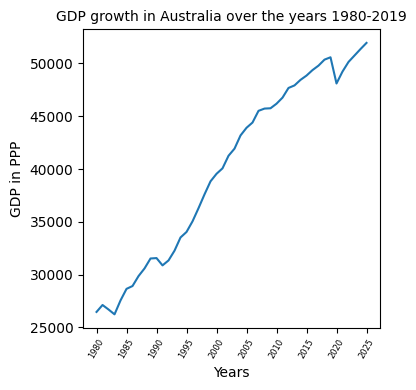

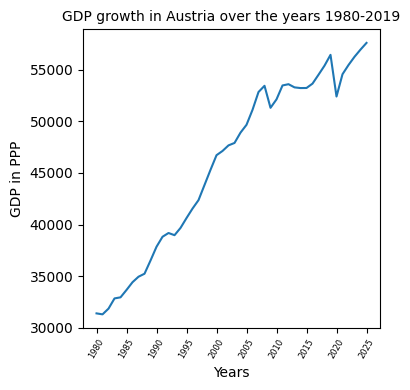

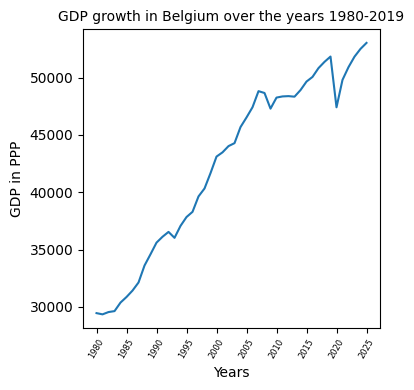

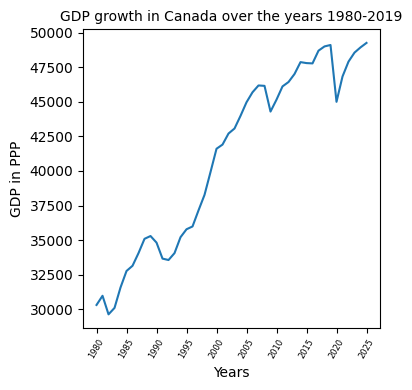

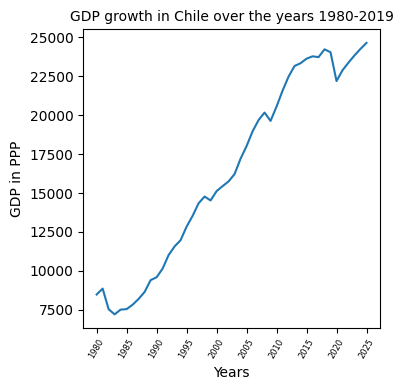

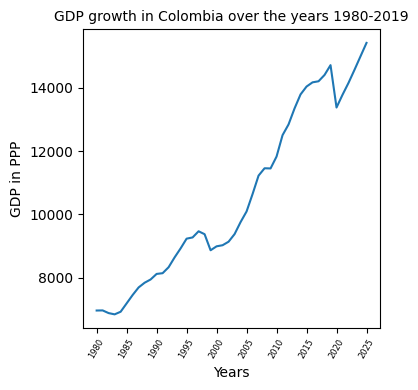

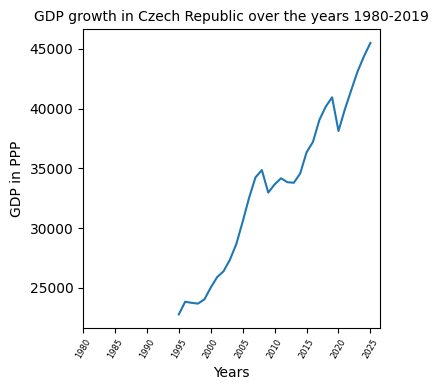

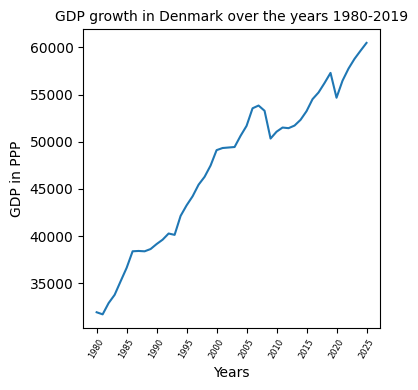

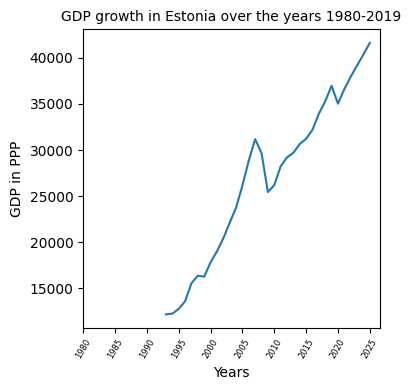

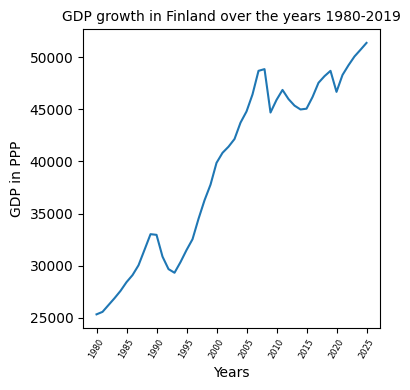

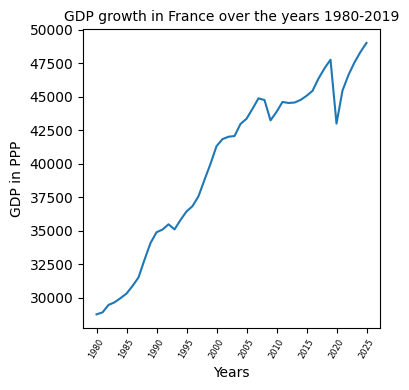

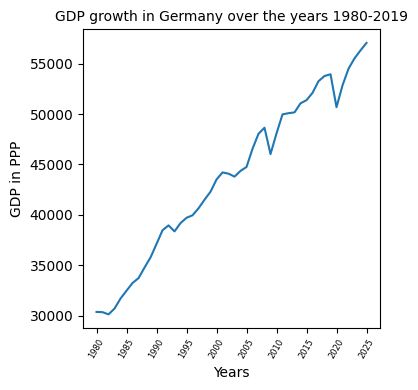

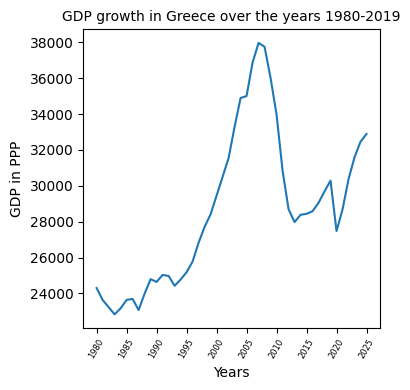

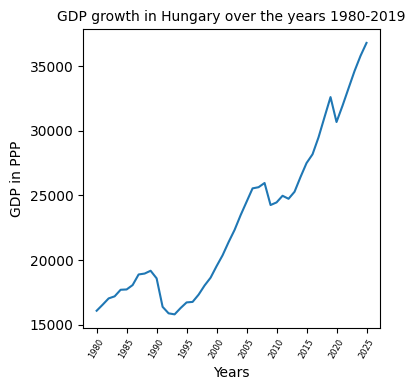

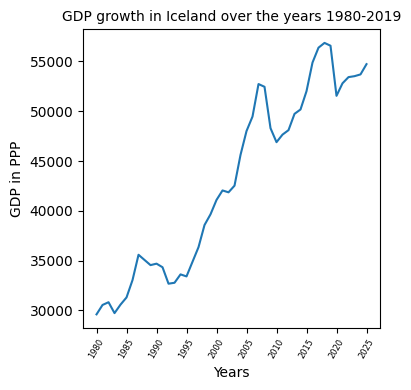

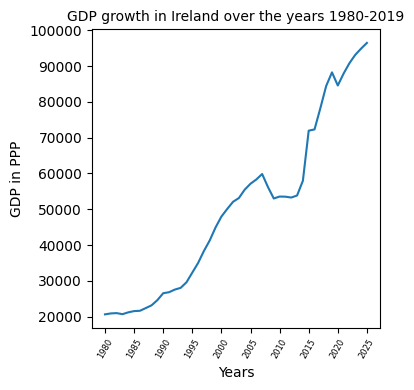

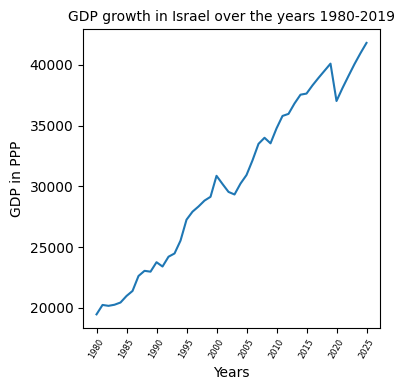

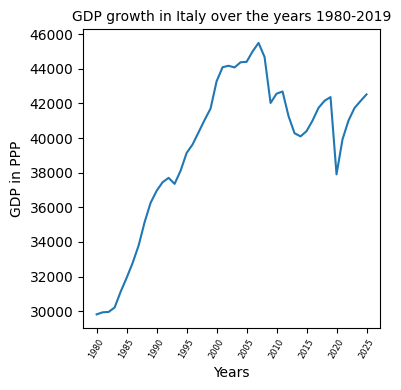

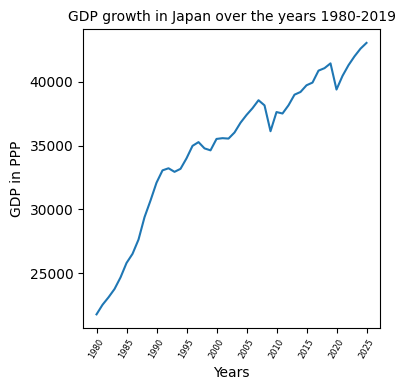

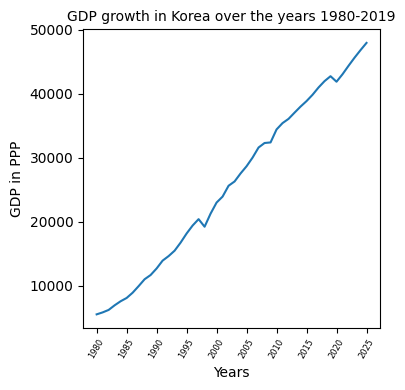

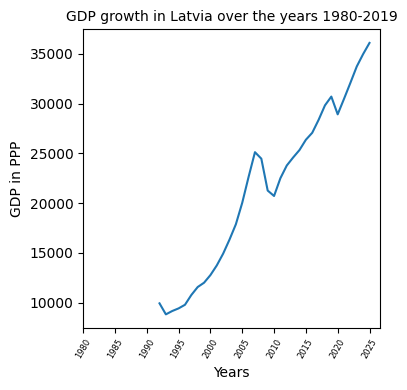

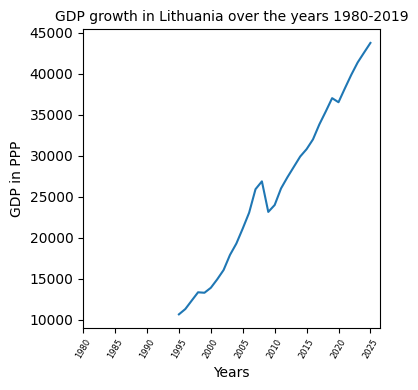

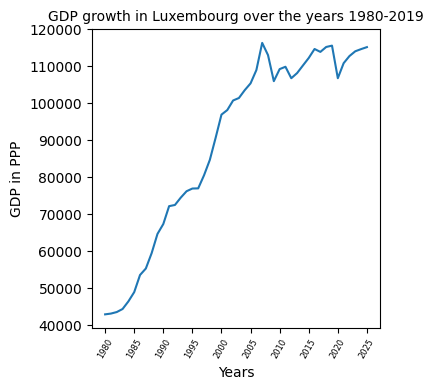

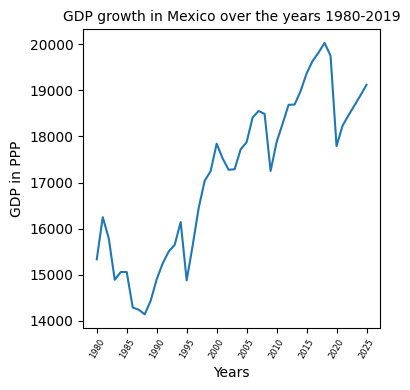

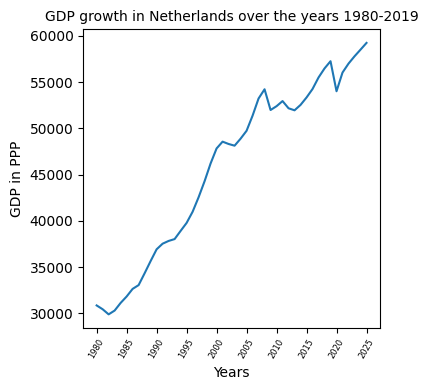

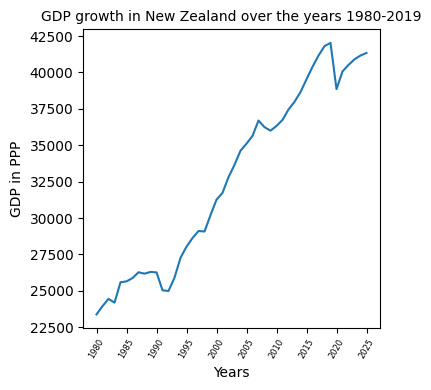

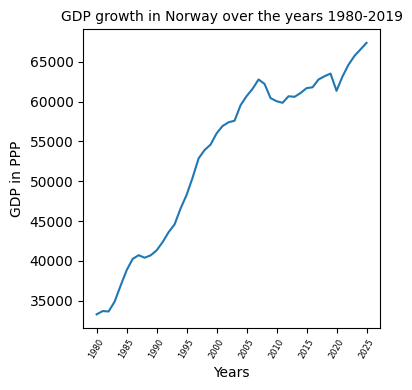

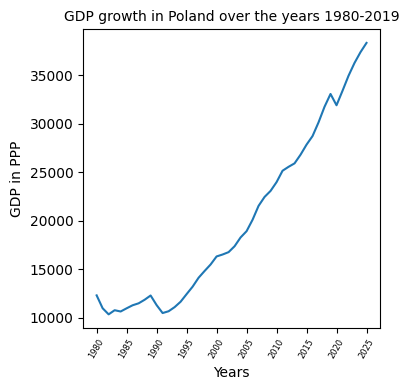

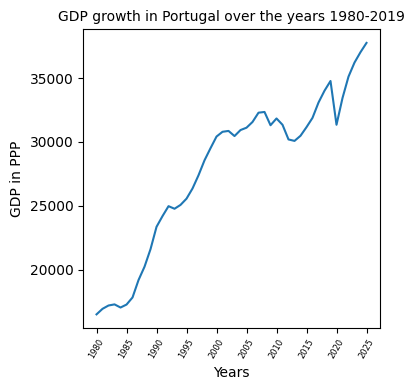

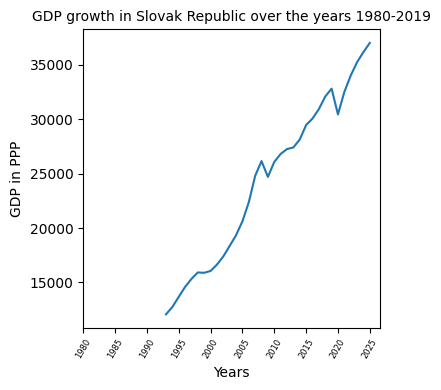

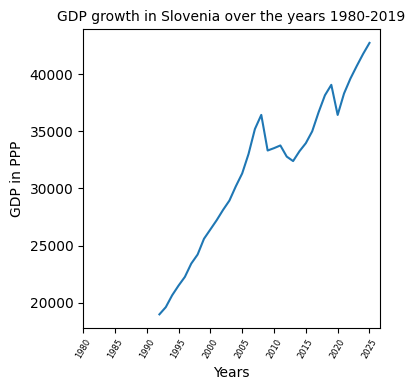

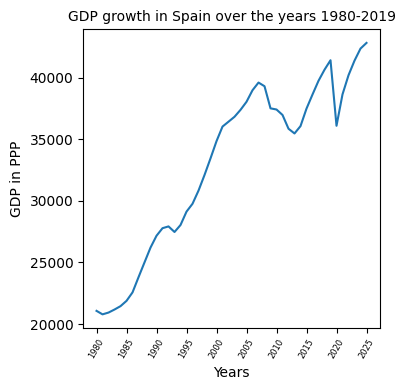

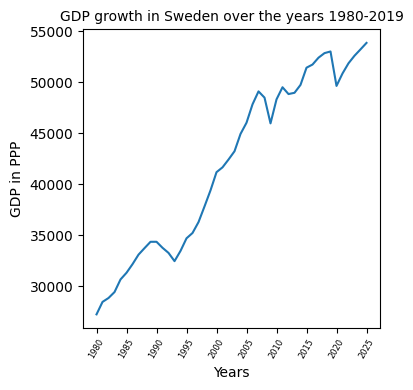

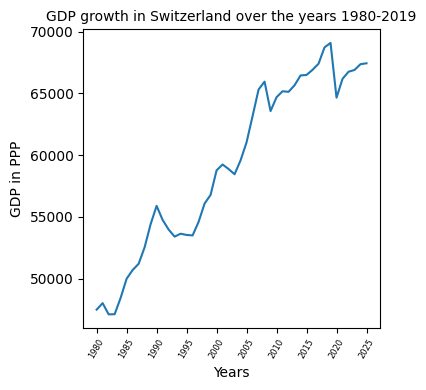

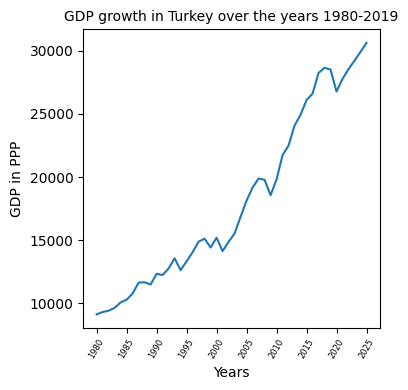

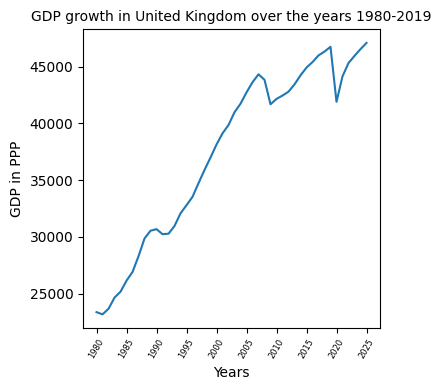

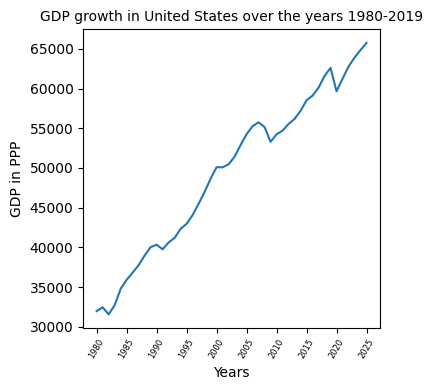

In [15]:
#Graphs of seperate OECD countries GDP growth
folder_path = 'GDP_graphs'
i=0
for country in OECD_countries_gdp['Country']:
    x=OECD_countries_gdp.columns[2:]
    y=OECD_countries_gdp.iloc[i][2:]
    plt.figure(figsize=(4,4))
    plt.xlabel('Years')
    plt.ylabel('GDP in PPP')
    plt.title('GDP growth in '+ country +' over the years 1980-2019', fontsize=10)
    plt.plot(x, y, label=country)
    i=i+1
    plt.xticks(np.arange(1980, 2026, 5), rotation=60, fontsize=6)
    plt.tight_layout()
    file_name = country+'.png'
    file_path = f'{folder_path}/{file_name}'
    plt.savefig(file_path)

In [16]:
#For the total GDP growth sum for each year is calculated
values_to_plot=OECD_countries_gdp.T.iloc[2:, :].sum(axis=1)

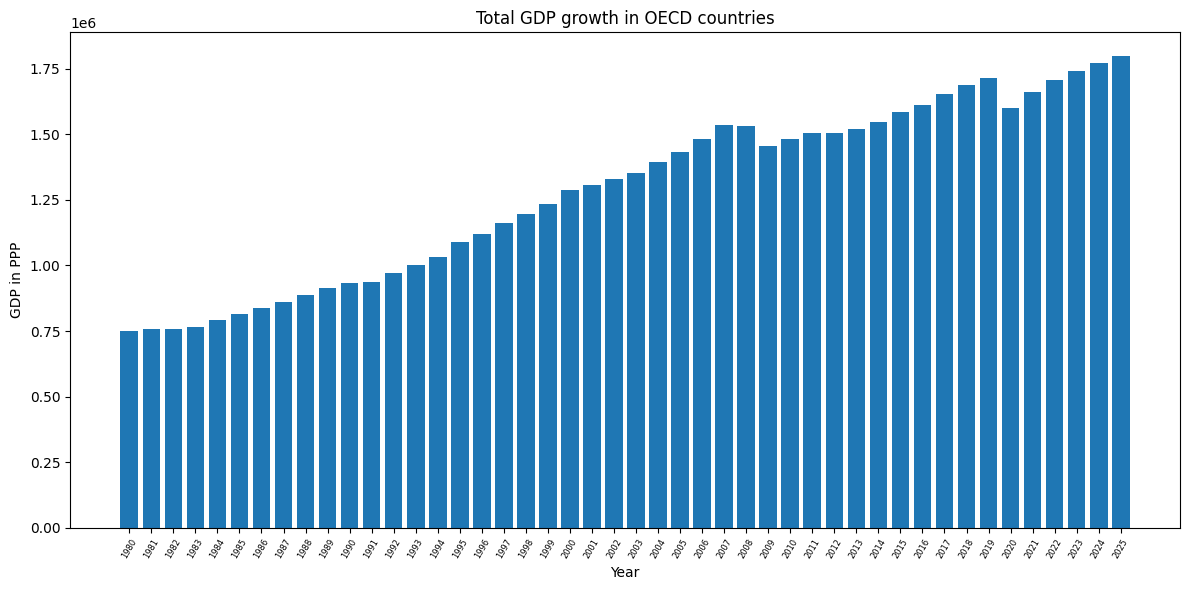

In [17]:
# Bar chart for total GDP growth in OECD countries
plt.figure(figsize=(12, 6)) 
plt.bar(OECD_countries_gdp.columns[2:], values_to_plot)
plt.xlabel('Year')
plt.ylabel('GDP in PPP')
plt.title(f'Total GDP growth in OECD countries')
plt.xticks(np.arange(1980, 2026, 1),rotation=60, fontsize=6)
plt.tight_layout()
file_name = 'total_GDP.png'
file_path = f'{folder_path}/{file_name}'
plt.savefig(file_path)
plt.show()


#### Part 4: 5 clusters out of the countries using GDP and "Volume of exports of goods"

In [27]:
clustering=df.drop(['WEO Country Code','ISO', 'Estimates Start After'], axis=1)

#Clustering based on Volume on export of goods (TXG_RPCH) and GDP constant prices, percentange change (NGDP_RPCH)
clustering=clustering[(clustering['WEO Subject Code']=='TXG_RPCH') | (clustering['WEO Subject Code']=='NGDP_RPCH')]

In [8]:
clustering.isnull().sum()

WEO Subject Code      0
Country               0
1980                137
1981                124
1982                123
1983                121
1984                121
1985                122
1986                119
1987                118
1988                118
1989                119
1990                117
1991                108
1992                105
1993                 78
1994                 75
1995                 71
1996                 61
1997                 59
1998                 53
1999                 46
2000                 43
2001                 31
2002                 30
2003                 27
2004                 27
2005                 26
2006                 26
2007                 26
2008                 26
2009                 26
2010                 26
2011                 28
2012                 26
2013                 25
2014                 25
2015                 19
2016                 19
2017                 19
2018                 19
2019            

In [28]:
#Based on the sum of null values some years with a lot of missing data are dropped
clustering=clustering.drop([1980, 1981, 1982, 1983,
                            1984, 1985, 1986, 1987,
                            1988, 1989, 1990, 1991,
                            1992, 1993, 1994, 1995,
                            1996, 1997, 1998, 1999], axis=1)

In [29]:
#Missing data is filled with backwawrds fill method
clustering=clustering.fillna(method='bfill')

In [30]:
#Dropping string columns to deal with numeric data
dropped=['WEO Subject Code', 'Country']
clustering=clustering.drop(dropped,axis=1)

In [31]:
clustering.apply(pd.to_numeric)

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
1,6.946,8.293,4.537,8.692,0.671,11.830,5.361,13.340,3.863,20.585,...,2.164,2.647,1.189,3.912,-5.000,4.000,4.524,4.500,4.009,4.012
24,6.946,8.293,4.537,87.548,-27.364,17.543,-33.218,39.065,50.728,-20.600,...,12.990,18.262,3.793,0.068,-27.053,34.963,26.897,9.360,9.244,10.325
46,6.946,8.293,4.537,5.529,5.515,5.526,5.903,5.983,7.500,3.354,...,3.315,3.802,4.071,2.240,-7.529,6.094,5.818,4.311,3.458,3.429
69,-7.088,23.048,8.253,25.150,24.013,2.948,5.256,19.958,-55.035,-15.636,...,-0.285,-1.647,14.139,-8.454,-5.733,12.205,15.316,14.174,4.383,3.920
91,3.800,3.000,5.600,7.200,4.300,5.900,1.684,3.373,2.360,1.632,...,3.200,1.300,1.400,0.800,-5.461,3.163,2.557,1.149,1.029,0.949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8664,2.540,0.417,6.186,-6.516,-6.189,-0.935,-4.456,-12.830,-4.284,-3.034,...,-74.984,38.423,18.862,30.832,-23.716,50.959,38.278,44.432,92.322,15.336
8686,3.897,5.317,4.506,6.945,7.032,7.236,7.904,8.352,7.774,9.220,...,3.757,3.524,4.035,1.442,-4.831,0.583,1.051,1.214,1.231,1.210
8709,-6.179,26.175,12.827,-3.207,16.950,6.293,6.303,3.096,7.407,19.198,...,-4.704,3.546,7.283,-12.488,-4.660,-2.686,0.904,0.555,2.302,6.109
8731,-4.231,-0.454,-7.704,-16.224,-6.270,-7.413,-3.556,-3.401,-16.323,7.396,...,0.742,4.704,3.497,-6.541,-10.378,4.158,2.485,2.160,2.160,2.160


In [32]:
#Concatanating yearly data into average
clustering=pd.DataFrame(clustering.mean(axis=1))

In [33]:
#Taking every other value for TXG_RPC column
TXG_RPCH=pd.DataFrame(clustering[1::2])
TXG_RPCH=TXG_RPCH.reset_index(drop=True)

In [34]:
#The same for NGDP_RPCH column
NGDP_RPCH=pd.DataFrame(clustering[0::2])
NGDP_RPCH=NGDP_RPCH.reset_index(drop=True)

In [35]:
countries=df['Country'].unique()

In [36]:
result_df = pd.concat([pd.Series(countries, name='Country'),NGDP_RPCH ,TXG_RPCH ], axis=1)
result_df.set_index('Country', inplace=True)

In [37]:
result_df.columns=['NGDP_RPCH','TXG_RPCH']

In [38]:
result_df.head()

,NGDP_RPCH,TXG_RPCH
Country,,
Afghanistan,5.704923,10.826385
Albania,3.875385,7.695462
Algeria,2.656346,-0.657577
Angola,4.732385,4.087423
Antigua and Barbuda,2.499308,0.352192


In [39]:
#Produces outliers so country is dropped
result_df=result_df.drop('Eritrea',axis=0)
result_df=result_df.drop('Venezuela', axis=0)

In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
scaler = StandardScaler()
result_df[['TXG_RPCH_S','NGDP_RPCH_S']] = scaler.fit_transform(result_df[['TXG_RPCH','NGDP_RPCH']])

In [42]:
kmeans=KMeans(n_clusters=5)

In [43]:
kmeans.fit(result_df[['TXG_RPCH_S','NGDP_RPCH_S']])

C:\Users\Iveta\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Iveta\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Iveta\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 217, in _count_physical_cores
    raise ValueError(
C:\Users\Iveta\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid

KMeans(n_clusters=5)

In [44]:
result_df['kmeans_5']=kmeans.labels_

In [45]:
result_df.head()

,NGDP_RPCH,TXG_RPCH,TXG_RPCH_S,NGDP_RPCH_S,kmeans_5
Country,,,,,
Afghanistan,5.704923,10.826385,1.695390,1.156155,0
Albania,3.875385,7.695462,0.765810,0.195913,2
Algeria,2.656346,-0.657577,-1.714233,-0.443905,1
Angola,4.732385,4.087423,-0.305428,0.645713,3
Antigua and Barbuda,2.499308,0.352192,-1.414429,-0.526328,1


In [46]:
#Finding the top countries in each cluster

top_country_0=result_df[result_df['kmeans_5']==0]
top_country_0_value=top_country_0['NGDP_RPCH'].max()
top_country_0=top_country_0[top_country_0['NGDP_RPCH']==top_country_0_value]

top_country_1=result_df[result_df['kmeans_5']==1]
top_country_1_value=top_country_1['NGDP_RPCH_S'].max()
top_country_1=top_country_1[top_country_1['NGDP_RPCH_S']==top_country_1_value]

top_country_2=result_df[result_df['kmeans_5']==2]
top_country_2_value=top_country_2['NGDP_RPCH_S'].max()
top_country_2=top_country_2[top_country_2['NGDP_RPCH_S']==top_country_2_value]

top_country_3=result_df[result_df['kmeans_5']==3]
top_country_3_value=top_country_3['NGDP_RPCH_S'].max()
top_country_3=top_country_3[top_country_3['NGDP_RPCH_S']==top_country_3_value]

top_country_4=result_df[result_df['kmeans_5']==4]
top_country_4_value=top_country_4['NGDP_RPCH_S'].max()
top_country_4=top_country_4[top_country_4['NGDP_RPCH_S']==top_country_4_value]


top_countries=pd.concat([top_country_0, top_country_1, top_country_2, top_country_3, top_country_4], ignore_index=False)

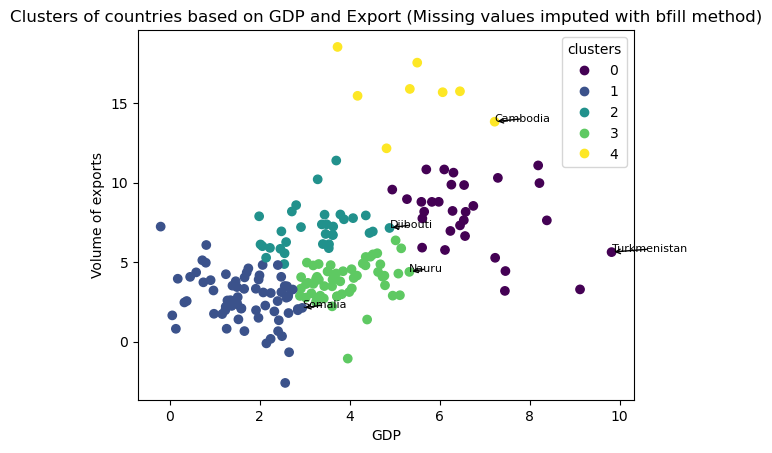

In [49]:
#Scatter plot for clusters with the top countries 
fig, ax = plt.subplots()
sc = ax.scatter(x=result_df['NGDP_RPCH'], y=result_df['TXG_RPCH'], c=result_df['kmeans_5'])
ax.legend(*sc.legend_elements(), title='clusters')
plt.title('Clusters of countries based on GDP and Export (Missing values imputed with bfill method)')
plt.xlabel('GDP')
plt.ylabel('Volume of exports')


for txt in top_countries.index:
    ax.annotate(txt, (top_countries.loc[txt, 'NGDP_RPCH'], top_countries.loc[txt, 'TXG_RPCH']),
    arrowprops=dict(facecolor='red', arrowstyle='->'),
    fontsize=8)
plt.show()

#### Part 5: Find all the data fields from the year 2015 that are present in most of the countries

In [50]:
most_present=df.loc[:,['Country', 'WEO Subject Code',
                                    2015, 2016, 2017, 2018,
                                    2019, 2020, 2021, 2022,
                                    2023, 2024, 2025]]

In [51]:
WEO_codes=most_present['WEO Subject Code'].unique()

In [52]:
#Iterating over all codes and summing null values
values={}
for code in WEO_codes:
    values[code]=most_present[most_present['WEO Subject Code']==code].isnull().sum().sum()

#Values in increasing order show the most present ones    
values = dict(sorted(values.items(), key=lambda item: item[1], reverse=False))
values

{'NGDP_RPCH': 19,
 'NGDP_D': 19,
 'NGDP': 22,
 'PPPGDP': 22,
 'NGDP_FY': 22,
 'PPPEX': 23,
 'NGDPD': 25,
 'NGDP_R': 26,
 'GGR': 27,
 'GGR_NGDP': 27,
 'NGDPRPC': 30,
 'NGDPRPPPPC': 30,
 'LP': 30,
 'BCA_NGDPD': 32,
 'NGDPPC': 33,
 'PPPPC': 33,
 'NGDPDPC': 36,
 'PCPI': 37,
 'PCPIE': 37,
 'PCPIEPCH': 38,
 'GGX': 38,
 'GGX_NGDP': 38,
 'GGXCNL': 38,
 'GGXCNL_NGDP': 38,
 'PCPIPCH': 39,
 'BCA': 39,
 'GGXWDG': 71,
 'GGXWDG_NGDP': 71,
 'PPPSH': 99,
 'GGXONLB_NGDP': 123,
 'GGXONLB': 124,
 'TX_RPCH': 201,
 'TMG_RPCH': 212,
 'TM_RPCH': 213,
 'TXG_RPCH': 213,
 'NID_NGDP': 261,
 'NGSD_NGDP': 277,
 'LUR': 993,
 'GGXWDN': 1190,
 'GGXWDN_NGDP': 1190,
 'GGSB': 1209,
 'GGSB_NPGDP': 1253,
 'LE': 1879,
 'NGAP_NPGDP': 1928,
 'FLIBOR6': 2131}

#### Part 6: Create a predictor (use scikit) to predict GDP per capita 

In [287]:
#Modifying the dataframe for model
data=df.copy()
data=data.drop(['WEO Country Code','ISO', 'Estimates Start After'], axis=1)
#Dropping earlier years and esmitated years
data = data.drop(data.columns[2:36], axis=1)
data=data.drop([2020,2021,2022,2023,2024,2025], axis=1)

#Dropping GDP related features
data=data[~data['WEO Subject Code'].isin(['NGDP_R', 'NGDP_RPCH', 'NGDP', 'NGDPD', 
                                          'PPPGDP', 'NGDP_D', 'NGDPRPC', 'NGDPPC',
                                          'NGDPDPC', 'PPPPC', 'PPPSH', 'NGDP_FY'])]
#Dropping features with a lot of missing data
data=data[~data['WEO Subject Code'].isin(['FLIBOR6', 'NGAP_NPGDP', 'LE', 'GGSB_NPGDP',
                                          'GGSB', 'GGXWDN_NGDP' ,'GGXWDN', 'LUR', 'NGSD_NGDP',
                                          'NID_NGDP', 'TXG_RPCH', 'TMG_RPCH', 'TM_RPCH', 'TX_RPCH'])]

#Dropping features that measure the same feature but are expressed in different measurements
data=data[~data['WEO Subject Code'].isin(['GGR', 'GGX', 'PCPI' 'PCPIE', 'BCA', 'GGXWDG', 'GGXONLB'])]

data=data.reset_index()

data=data.drop('index', axis=1)
data.columns=data.columns.astype(str)


#Replacing 0 values with NaN for an easier imputation

data=data.replace(0, np.nan)



In [162]:
data.head()

,WEO Subject Code,Country,2014,2015,2016,2017,2018,2019
0,NGDPRPPPPC,Afghanistan,2153.574,2111.764,2100.222,2102.784,2078.476,2111.253
1,PPPEX,Afghanistan,17.036,17.023,17.446,17.206,17.150,17.948
2,PCPI,Afghanistan,101.970,101.296,105.736,110.998,111.693,114.264
3,PCPIPCH,Afghanistan,4.674,-0.662,4.384,4.976,0.626,2.302
4,PCPIE,Afghanistan,103.053,104.218,109.000,112.315,113.162,116.300


In [209]:
WEO_codes=data['WEO Subject Code'].unique()

In [163]:
#Inspecting for null values
values={}
for code in WEO_codes:
    values[code]=data[data['WEO Subject Code']==code].isnull().sum().sum()
    
values = dict(sorted(values.items(), key=lambda item: item[1], reverse=False))
values

{'GGR_NGDP': 6,
 'PPPEX': 8,
 'NGDPRPPPPC': 12,
 'LP': 12,
 'GGX_NGDP': 12,
 'GGXCNL': 12,
 'GGXCNL_NGDP': 12,
 'PCPIE': 13,
 'PCPI': 14,
 'PCPIPCH': 15,
 'BCA_NGDPD': 15,
 'PCPIEPCH': 18,
 'GGXWDG_NGDP': 36,
 'GGXONLB_NGDP': 56}

In [164]:
data.describe()

,2014,2015,2016,2017,2018,2019
count,2.687000e+03,2.685000e+03,2.689000e+03,2.693000e+03,2.693000e+03,2.692000e+03
mean,1.965006e+10,2.160419e+10,2.318743e+10,2.389262e+10,2.477798e+10,2.578932e+10
std,7.201776e+11,7.916026e+11,8.501010e+11,8.765885e+11,9.090718e+11,9.458298e+11
min,-2.476755e+05,-3.000887e+05,-3.083409e+05,-3.409770e+05,-3.529062e+05,-1.348659e+06
25%,1.850000e-01,-5.000000e-02,1.030000e-01,5.310000e-01,7.550000e-01,5.507500e-01
50%,1.132100e+01,1.178100e+01,1.236100e+01,1.283900e+01,1.335100e+01,1.272150e+01
75%,8.154450e+01,8.309000e+01,9.012800e+01,9.276800e+01,9.677600e+01,9.999400e+01
max,2.675137e+13,2.960668e+13,3.146837e+13,3.239585e+13,3.360923e+13,3.505646e+13


In [61]:
#Inspecting the null values. 
rows_with_nulls = data[data.isnull().any(axis=1)]

# Display the result
print(rows_with_nulls)

     WEO Subject Code              Country    2012    2013     2014   2015  \
69          BCA_NGDPD  Antigua and Barbuda     NaN     NaN    0.267  2.194   
72               PCPI            Argentina  78.603  86.950      NaN    NaN   
73            PCPIPCH            Argentina  10.043  10.619      NaN    NaN   
74              PCPIE            Argentina  82.471  91.498  113.380    NaN   
75           PCPIEPCH            Argentina  10.842  10.946   23.915    NaN   
...               ...                  ...     ...     ...      ...    ...   
2419     GGXONLB_NGDP             Thailand     NaN   1.267   -0.061  0.713   
2427         PCPIEPCH          Timor-Leste   9.202   4.034    0.306 -0.610   
2517     GGXONLB_NGDP         Turkmenistan     NaN     NaN      NaN    NaN   
2647            PPPEX            Venezuela     NaN     NaN      NaN    NaN   
2685     GGXONLB_NGDP   West Bank and Gaza     NaN     NaN      NaN    NaN   

         2016     2017     2018     2019  
69     -2.428   -7.8

In [288]:
#Imputing missing data
#Some countries do not have any value in certain rows, in that case, the 2012 column
#is imputed with 0 value for a ffill method later on
data.iloc[:, 2] = data.iloc[:, 2].fillna(0)

#Some rows don't have the last values, in that case if it's not filled with backwards fill, 
#null values are imputed with forward fill
data=data.fillna(method='bfill', axis=1)
data=data.fillna(method='ffill', axis=1)

In [289]:
from sklearn.preprocessing import StandardScaler

In [290]:
#Goal is to reshape the data in a way similar to one-hot encoding. Each WEO subject gets a seperate column for every year

# Identify the columns to be melted (years in this case)
years_columns = data.columns.difference(['WEO Subject Code', 'Country'])

# Use pd.melt with specified value_vars
melted_df = pd.melt(data, id_vars=['WEO Subject Code', 'Country'], value_vars=years_columns, var_name='Year', value_name='Value')

# Create a new column for encoding
melted_df['Encoded_Column'] = 'WEO subject_' + melted_df['WEO Subject Code'] + '_' + melted_df['Year']

# Pivot the DataFrame to get the desired format
reshaped_df = melted_df.pivot(index='Country', columns='Encoded_Column', values='Value')

# Reset the index to make 'Country' a regular column
reshaped_df.reset_index(inplace=True)

# Rename the index column
reshaped_df.rename_axis(None, axis=1, inplace=True)
reshaped_df.set_index('Country', inplace=True)


from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

#Standartize the data
#scaler = StandardScaler()

columns_to_scale = reshaped_df.columns[:]
reshaped_df[columns_to_scale] = scaler.fit_transform(reshaped_df[columns_to_scale])



In [167]:
reshaped_df.describe()

,WEO subject_BCA_NGDPD_2014,WEO subject_BCA_NGDPD_2015,WEO subject_BCA_NGDPD_2016,WEO subject_BCA_NGDPD_2017,WEO subject_BCA_NGDPD_2018,WEO subject_BCA_NGDPD_2019,WEO subject_GGR_NGDP_2014,WEO subject_GGR_NGDP_2015,WEO subject_GGR_NGDP_2016,WEO subject_GGR_NGDP_2017,...,WEO subject_PCPI_2016,WEO subject_PCPI_2017,WEO subject_PCPI_2018,WEO subject_PCPI_2019,WEO subject_PPPEX_2014,WEO subject_PPPEX_2015,WEO subject_PPPEX_2016,WEO subject_PPPEX_2017,WEO subject_PPPEX_2018,WEO subject_PPPEX_2019
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,1.950000e+02,1.950000e+02,1.950000e+02,1.950000e+02,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,0.055453,-0.055517,-0.057742,0.012426,0.029507,0.012594,0.187039,0.208794,0.162393,0.161934,...,2.385141e+09,2.415021e+09,2.296903e+09,2.016063e+09,3.161229,3.144197,2.872772,2.835329,3.033747,3.382251
std,1.349957,1.091168,1.215679,1.056770,1.180123,1.105710,0.927738,1.062829,1.121543,1.043479,...,3.330661e+10,3.372386e+10,3.207441e+10,2.814971e+10,12.770323,12.893130,12.060686,12.139533,14.037593,17.927636
min,-7.939590,-5.116124,-5.785665,-2.835788,-5.035686,-3.856086,-1.514557,-1.605211,-1.653491,-1.596014,...,-1.648160e+00,-1.682553e+00,-1.594890e+00,-1.393349e+00,-0.056172,-0.055993,-0.054459,-0.055747,-0.055414,-0.056721
25%,-0.475543,-0.540995,-0.461067,-0.518862,-0.450262,-0.417313,-0.388684,-0.431400,-0.488434,-0.458278,...,-1.405658e-01,-1.768404e-01,-1.883271e-01,-1.875919e-01,-0.043256,-0.044214,-0.043521,-0.045245,-0.044856,-0.045939
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.524457,0.459005,0.538933,0.481138,0.549738,0.582687,0.611316,0.568600,0.511566,0.541722,...,8.594342e-01,8.231596e-01,8.116729e-01,8.124081e-01,0.956744,0.955786,0.956479,0.954755,0.955144,0.954061
max,8.158131,3.576825,4.071361,4.665180,4.994283,4.473569,6.968259,7.511426,7.880895,7.335654,...,4.651016e+11,4.709281e+11,4.478948e+11,3.930895e+11,125.237419,131.176642,128.074954,133.057062,165.655670,228.262672


In [42]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [291]:
#The value we are trying to predict is coded NGDPRPPPPC in 2019
y=reshaped_df['WEO subject_NGDPRPPPPC_2019']
reshaped_df=reshaped_df.drop('WEO subject_NGDPRPPPPC_2019', axis=1)

In [292]:
from sklearn.model_selection import train_test_split 

In [310]:
X_train, X_test, y_train, y_test = train_test_split(reshaped_df,y)

In [72]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(146, 111)
(49, 111)
(146,)
(49,)


In [303]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [311]:
model=LinearRegression() 
model.fit(X_train,y_train)

LinearRegression()

In [312]:
predictions = model.predict(X_test)

# Regression metrics
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Display regression metrics
print(f'Mean Squared Error (MSE): {mse}')
print(f'R-squared (R2): {r2}')

Mean Squared Error (MSE): 0.09846210608678063
R-squared (R2): 0.7656180588501631


In [233]:
predictions

array([ 2.99110200e-01, -4.46877591e-02, -7.85871919e-01,  3.80056328e+09,
       -9.19159018e-02, -8.32638223e-01, -4.19603512e-02, -9.15215995e-01,
       -6.12431426e-01, -7.82545757e-01, -9.25312042e-02, -9.18226756e-01,
       -3.17068551e-01,  4.66419007e+01, -3.82469818e-01, -9.86233134e-01,
       -4.41150118e-01, -8.66224166e-01,  5.06856441e-02, -4.94493604e-01,
       -6.82943974e-01, -4.30305942e+06, -7.16107082e-01, -6.17445752e-01,
        1.67916698e+00,  6.01281714e-01, -5.75134907e-01, -8.46613951e-01,
       -7.88840942e-01,  1.38761986e+00, -9.45669703e-01, -1.23872753e-01,
       -1.26931145e+01,  1.10650122e-01,  4.60230302e-01, -1.62460946e-01,
       -8.17514610e-01,  7.25390092e-02, -2.71452889e-02,  4.58815895e-01,
        8.55211139e-01,  5.14656905e+01, -5.11842042e-01, -1.01358142e-01,
       -8.18496831e-01, -9.62323967e-01, -8.89148537e-01, -6.73939887e-01,
        1.56734096e+00])

In [234]:
y_test

Country
Malaysia                    0.319840
Mexico                     -0.050242
Cameroon                   -0.786485
Brazil                     -0.281160
Indonesia                  -0.406773
Burkina Faso               -0.855794
Dominican Republic         -0.080403
Uganda                     -0.839742
Liberia                    -0.885764
Bangladesh                 -0.726604
Egypt                      -0.410828
Togo                       -0.883302
Albania                    -0.316493
Moldova                    -0.364631
South Africa               -0.385704
Chad                       -0.883416
Tunisia                    -0.466549
Mozambique                 -0.898932
Mauritius                   0.092173
Namibia                    -0.503780
Honduras                   -0.694499
Venezuela                  -0.632970
Myanmar                    -0.734309
Timor-Leste                -0.813382
Iceland                     1.639182
Sudan                      -0.773988
Morocco                    -0.

In [250]:
#Function for cross-validation
from sklearn.model_selection import cross_val_score

def cross_validation(model, X_train, y_train):
    fold=5

    scores=cross_val_score(model,X_train,y_train,cv=fold, scoring='neg_mean_squared_error')
    df=pd.DataFrame(data={'model':range(fold), 'mean_squared_error':scores})

    df.plot(x='model',y='mean_squared_error', marker='o', linestyle='--')

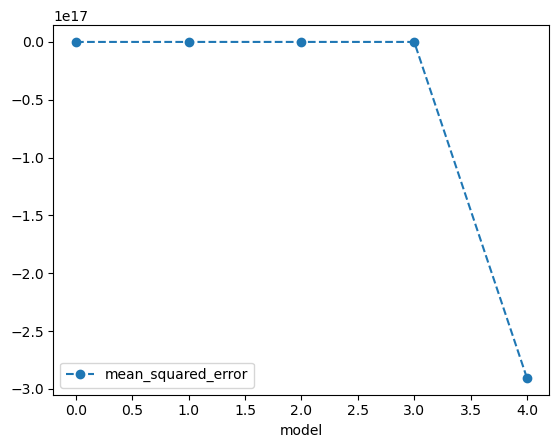

In [251]:
#Doing cross-validation for model stability
cross_validation(model, X_train, y_train)


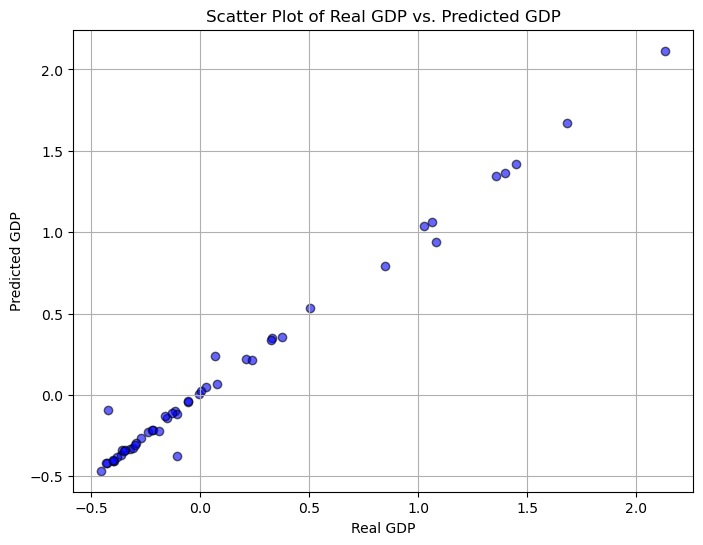

In [252]:
#Plotting actual GDP and predicted GDP
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.6, color='b', edgecolors='k')
plt.title('Scatter Plot of Real GDP vs. Predicted GDP')
plt.xlabel('Real GDP')
plt.ylabel('Predicted GDP')
plt.grid(True)
plt.show()

In [227]:
residuals = y_test - predictions

In [228]:
max_residual_index = np.argmax(np.abs(residuals))

In [229]:
max_residual_index 


48

### After doing some experiments and analysing the data I came to these conclusions: 
    model works almost perfectly most of the time. In the cross-validation graph MSE goes down significantly when an outlier is in the set. All other points are predicted accurately except for the outlier. 
    After inspecting the data, it is hard to tell, which countries produce such outliers and it requires a more in depth analysis.

In [296]:
from sklearn.decomposition import PCA

In [297]:
#Top 5 features using PCA
pca = PCA(n_components = 5)
 
X_train_pc = pca.fit_transform(X_train)
X_test_pc = pca.transform(X_test)
 
explained_variance = pca.explained_variance_ratio_

In [298]:
explained_variance

array([9.99999995e-01, 5.35166766e-09, 1.10572361e-13, 3.59404856e-17,
       2.04595908e-18])

In [313]:
feature_importances_lr = model.coef_

In [314]:
feature_importance_lr_df = pd.DataFrame({'Feature': reshaped_df.columns, 'Importance': feature_importances})
top_features_lr = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

In [315]:
top_features

,Feature,Importance
43,WEO subject_LP_2015,1.401553
52,WEO subject_NGDPRPPPPC_2018,1.322573
46,WEO subject_LP_2018,1.241559
50,WEO subject_NGDPRPPPPC_2016,0.195480
49,WEO subject_NGDPRPPPPC_2015,0.077469


#### Linear regression is not robust to outliers, depending on the X_train set, different features can be chosen an they are not significantly important

#### For that reason, random forest works better, MSE variance is smaller and the top features are not dependant on the set

In [324]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(1000, max_depth=10)
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)
    
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)


MSE: 0.004456909506756763


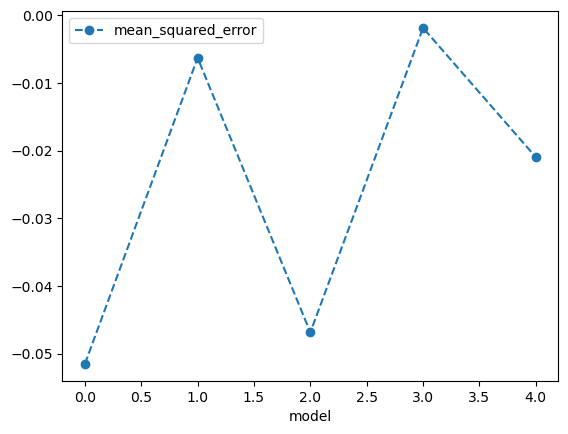

In [325]:
cross_validation(model_rf, X_train, y_train)

In [326]:
# Get feature importances
feature_importances_rf = model_rf.feature_importances_

feature_importance_rf_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})

top_features_rf = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

print("Top 5 Features:")
print(top_features_rf)

Top 5 Features:
                        Feature  Importance
52  WEO subject_NGDPRPPPPC_2018    0.404057
51  WEO subject_NGDPRPPPPC_2017    0.297360
49  WEO subject_NGDPRPPPPC_2015    0.114770
50  WEO subject_NGDPRPPPPC_2016    0.112427
48  WEO subject_NGDPRPPPPC_2014    0.045103


Features seem logical and hold a lot of significance

#### Building a predictor with top 5 features

In [328]:
tf=reshaped_df[['WEO subject_NGDPRPPPPC_2018',
                'WEO subject_NGDPRPPPPC_2017',
                'WEO subject_NGDPRPPPPC_2016',
                'WEO subject_NGDPRPPPPC_2015',
                'WEO subject_NGDPRPPPPC_2014']]

In [329]:
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(tf,y)

In [335]:
model_tf=RandomForestRegressor(1000, max_depth=10)
model_tf.fit(X_train_tf,y_train_tf)

RandomForestRegressor(max_depth=10, n_estimators=1000)

In [331]:
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)
    
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.00450564911200474


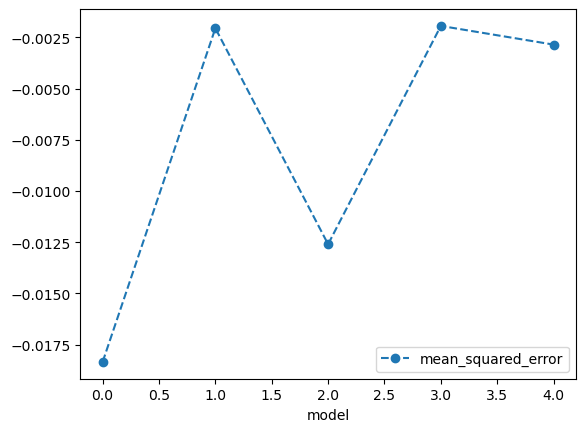

In [332]:
cross_validation(model_tf, X_train_tf, y_train_tf)

#### MSE dropped even more, which suggests that model is more stable and the variance is smaller.


In [333]:
#tf.rename(columns={'WEO subject_NGDPRPPPPC_2018':'year_1', 'WEO subject_NGDPRPPPPC_2017':'year_2',
                   'WEO subject_NGDPRPPPPC_2016':'year_3', 'WEO subject_NGDPRPPPPC_2015':'year_4',
                   'WEO subject_NGDPRPPPPC_2014':'year_5'})

,year_1,year_2,year_3,year_4,year_5
Country,,,,,
Afghanistan,-0.408930,-0.416257,-0.428089,-0.412229,-0.411226
Albania,0.039121,0.026212,0.009469,0.006509,0.000000
Algeria,-0.048718,-0.039422,-0.033901,-0.023892,-0.025398
Angola,-0.204393,-0.191542,-0.184755,-0.150573,-0.139749
Antigua and Barbuda,0.333743,0.312276,0.312876,0.295998,0.289077
...,...,...,...,...,...
Vietnam,-0.120230,-0.138600,-0.161372,-0.165156,-0.180745
West Bank and Gaza,-0.259343,-0.258442,-0.262756,-0.263001,-0.264639
Yemen,-0.412558,-0.419387,-0.424132,-0.396285,-0.351359


In [337]:
#To save the model
import joblib

joblib.dump(model_tf, 'random_forest_model.joblib')


['random_forest_model.joblib']